Exercises:
Conceptual


(1)

Using the basic property of variance for a linear combination of two random variables, $\text{Var}(aX + bY) = a^2 \text{Var}(X) + b^2 \text{Var}(Y) + 2ab \text{Cov}(X,Y)$:

$f(\alpha) = \alpha^2 \text{Var}(X) + (1 - \alpha)^2 \text{Var}(Y) + 2\alpha(1 - \alpha)\text{Cov}(X, Y)$

$\text{Var}(X) = \sigma_X^2$, $\text{Var}(Y) = \sigma_Y^2$, and $\text{Cov}(X,Y) = \sigma_{XY}$:

$f(\alpha) = \alpha^2 \sigma_X^2 + (1 - \alpha)^2 \sigma_Y^2 + 2(\alpha - \alpha^2) \sigma_{XY}$


To find the minimum, take the first derivative of $f(\alpha)$ with respect to $\alpha$:

$\frac{df}{d\alpha} = 2\alpha \sigma_X^2 + 2(1 - \alpha)(-1) \sigma_Y^2 + 2(1 - 2\alpha) \sigma_{XY}$



$\frac{df}{d\alpha} = 2\alpha \sigma_X^2 - 2(1 - \alpha)\sigma_Y^2 + 2(1 - 2\alpha)\sigma_{XY}$


$\frac{df}{d\alpha} = 2 \left[ \alpha \sigma_X^2 - \sigma_Y^2 + \alpha \sigma_Y^2 + \sigma_{XY} - 2\alpha \sigma_{XY} \right]$


$\alpha \sigma_X^2 - \sigma_Y^2 + \alpha \sigma_Y^2 + \sigma_{XY} - 2\alpha \sigma_{XY} = 0$

$\alpha \left(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}\right) - \sigma_Y^2 + \sigma_{XY} = 0$

$\alpha \left(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}\right) = \sigma_Y^2 - \sigma_{XY}$


$\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}$


$$\frac{d^2f}{d\alpha^2} = 2(\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}) = 2\text{Var}(X - Y)$$

Since the variance of any non-degenerate random variable is strictly positive ($\text{Var}(X - Y) > 0$), the second derivative is positive, confirming that this value of $\alpha$ indeed **minimizes** the variance.

Exercise 2:

(a)

In a bootstrap sample, $n$ observations are drawn uniformly at random **with replacement** from an original dataset of size $n$.

1. On any single draw, the probability of selecting the $j\text{th}$ observation is $\frac{1}{n}$.
2. By the complement rule, the probability of **not** selecting the $j\text{th}$ observation on the first draw is:

$P(\text{not } j\text{th}) = 1 - \frac{1}{n} = \frac{n - 1}{n}$

(b)

Because bootstrap sampling is performed **with replacement**, each draw is independent and identically distributed. The outcome of the first draw does not alter the probabilities of the second draw.

Thus, the probability that the second bootstrap observation is not the $j\text{th}$ observation is identical to that of the first draw:

$P(\text{2nd draw is not } j\text{th}) = 1 - \frac{1}{n} = \frac{n - 1}{n}$

(c)

A bootstrap sample takes $n$ total independent draws. For observation $j$ to be completely left out, it must be missed on every single draw:


$P(\text{not in sample}) = {\left(1 - \frac{1}{n}\right) \times \left(1 - \frac{1}{n}\right)\dots \times \left(1 - \frac{1}{n}\right)}_{n \text{ times}} = \left(1 - \frac{1}{n}\right)^n$

(d)

Using the complement rule along with the result from part (c):

$P(j\text{th} \text{ observation is in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n$

For $n = 5$:

$P = 1 - \left(1 - \frac{1}{5}\right)^5 = 1 - \left(\frac{4}{5}\right)^5 = 1 - 0.32768 = 0.67232$

There is a **67.23%** chance that the $j\text{th}$ observation is included in the bootstrap sample.

(e)

Using the complement rule:

$P(j\text{th} \text{ observation is in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n$

For $n = 100$:

$P = 1 - \left(1 - \frac{1}{100}\right)^{100} = 1 - (0.99)^{100} \approx 1 - 0.36603 = 0.63397$

There is a **63.40%** chance that the $j\text{th}$ observation is included in the bootstrap sample.

(f)

Using the complement rule:

$P(j\text{th} \text{ observation is in sample}) = 1 - \left(1 - \frac{1}{n}\right)^n$

For $n = 10000$:

$$P = 1 - \left(1 - \frac{1}{10000}\right)^{10000} = 1 - (0.9999)^{10000} \approx 1 - 0.36786 = 0.63214$$

There is a **63.21%** chance that the $j\text{th}$ observation is included in the bootstrap sample.


(g)

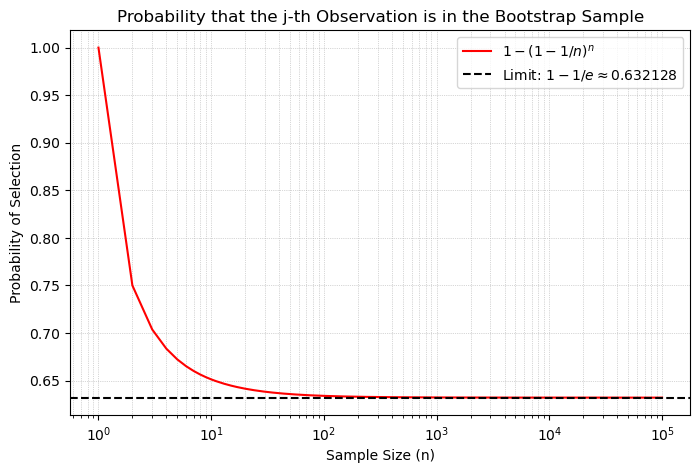

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n_values = np.arange(1, 100001)

probabilities = 1 - (1 - 1 / n_values) ** n_values

plt.figure(figsize=(8, 5))
plt.plot(n_values, probabilities, label=r"$1 - (1 - 1/n)^n$", color="red")
plt.axhline(y=1 - 1 / np.e, color="black", linestyle="--", label=r"Limit: $1 - 1/e \approx 0.632128$")
plt.xscale("log") 
plt.xlabel("Sample Size (n)")
plt.ylabel("Probability of Selection")
plt.title("Probability that the j-th Observation is in the Bootstrap Sample")
plt.legend()
plt.grid(True, which="both", linestyle=":", linewidth=0.5)
plt.show()

In [10]:
#(h)
rng = np.random.default_rng(10)
store = np.empty(10000)

for i in range(10000):
    store[i] = np.sum(rng.choice(100, size=100, replace=True) == 4) > 0

print(np.mean(store))

0.6362


The simulation result closely matches the theoretical probability of 0.6340 (63.40%) derived in part (e), empirically confirming our theoretical derivation.

Exercise 3:

(a):

First, it splits dataset randomly into $K$ equal groups (folds).

Next, pick one fold to serve as the validation set, and train your model on the remaining $K-1$ folds. Calculate the prediction error on that test fold.

Repeat this process $K$ times so every fold acts as the test set exactly once. Finally, average the $K$ error scores to get your overall test error estimate.


(b) Advantages and Disadvantages

- the Validation Set Approach

**Advantages:** It uses more data for training (e.g., 90% for $K=10$ versus 50%), which reduces bias and avoids overestimating test error. It also averages results across multiple folds, giving a much more stable estimate that depends less on a single random split.

**Disadvantage:** It takes $K$ times longer to compute because you must fit the model $K$ times instead of just once.

- LOOCV ($K = n$)

**Advantages:** It is drastically faster to run because fitting $5$ or $10$ models requires far less computation than fitting $n$ models. It also has lower overall variance: LOOCV models train on almost identical datasets, making their outputs heavily correlated, which inflates the variance of the average score.

**Disadvantage:** It has slightly higher bias because each training set leaves out a larger portion of data compared to LOOCV's $n-1$ observations.

Exercise 4

We estimate the standard deviation (standard error) of our prediction $\hat{Y}_0$ at a specific point $X_0$ using the **bootstrap method**:

1. **Resample:** Generate $B$ bootstrap datasets by sampling $n$ observations from the original data with replacement.
2. **Fit Models:** Fit the statistical learning model on each bootstrap sample $b \in \{1, 2, \dots, B\}$.
3. **Predict:** Obtain the predicted response $\hat{Y}_0^{*b}$ at $X = X_0$ for each fitted model.
4. **Compute Standard Deviation:** Calculate the standard error of these predictions:

$$\text{SE}(\hat{Y}_0) = \sqrt{\frac{1}{B-1}\sum_{b=1}^{B} \left(\hat{Y}_0^{*b} - \bar{\hat{Y}}_0\right)^2}$$



where $\bar{\hat{Y}}_0 = \frac{1}{B}\sum_{b=1}^{B} \hat{Y}_0^{*b}$.

Applied:

In [11]:
import pandas as pd
import statsmodels.api as sm

default = pd.read_csv(r"C:\Users\Fatima zahra\Practice\ALL+CSV+FILES+-+2nd+Edition+-+corrected\ALL CSV FILES - 2nd Edition\Default.csv")
default = default.dropna()

In [12]:
default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   default  10000 non-null  object 
 1   student  10000 non-null  object 
 2   balance  10000 non-null  float64
 3   income   10000 non-null  float64
dtypes: float64(2), object(2)
memory usage: 312.6+ KB


In [15]:
default.head()

,default,student,balance,income
0,No,No,-0.218824,0.813147
1,No,Yes,-0.037614,-1.605415
2,No,No,0.492386,-0.131206
3,No,No,-0.632861,0.164023
4,No,No,-0.102786,0.370897


In [19]:
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

default['default_'] = np.where(default['default'] == 'Yes', 1, 0)

design = MS(['income', 'balance'])
X = design.fit_transform(default)
y = default['default_']

glm = sm.GLM(y, X, family=sm.families.Binomial())
results = glm.fit()

print(summarize(results))

             coef  std err       z  P>|z|
intercept -6.1256    0.188 -32.657    0.0
income     0.2775    0.066   4.174    0.0
balance    2.7316    0.110  24.835    0.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [21]:
from sklearn.linear_model import LogisticRegression


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)



lr_preds = log_reg.predict(X_test_scaled)


lr_cm = pd.DataFrame(
    confusion_matrix(y_test, lr_preds),
    index=['Actual 0', 'Actual 1'],
    columns=['Pred 0', 'Pred 1']
)

lr_error = 1 - accuracy_score(y_test, lr_preds)

print(lr_cm)
print(f"\nTest Error Rate Logistic Regression: {lr_error:.2%}")

          Pred 0  Pred 1
Actual 0    1921       5
Actual 1      53      21

Test Error Rate Logistic Regression: 2.90%


In [31]:
#(b)


default_train, default_valid = train_test_split(default, test_size=5000, random_state=0)

design = MS(['income', 'balance'])
X_train = design.fit_transform(default_train)
y_train = default_train['default_']

model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = model.fit()

X_valid = design.transform(default_valid)
y_valid = default_valid['default_']

valid_probs = results.predict(X_valid)
valid_preds = valid_probs > 0.5

validation_error = np.mean(y_valid != valid_preds)

print(f"Validation Error Rate: {validation_error:.2%}")

Validation Error Rate: 2.90%


(c)

By changing the test_size, the Error Rate , slightly changes , it stays in the range of [0.02, 0.029] 

In [54]:

X_train = default_train[['income', 'balance', 'student']]
X_train = pd.get_dummies(X_train, columns=['student'], drop_first=True, dtype=float)

y_train = (default_train['default'] == 'Yes').astype(int)


X_valid = default_valid[['income', 'balance', 'student']]
X_valid = pd.get_dummies(X_valid, columns=['student'], drop_first=True, dtype=float)

y_valid = (default_valid['default'] == 'Yes').astype(int)



classifier = LogisticRegression(penalty=None)
classifier.fit(X_train, y_train)
valid_preds = clf.predict(X_valid)
validation_error = np.mean(y_valid != valid_preds)

print(f"Validation Error Rate: {validation_error:.2%}")

Validation Error Rate: 2.92%


Exercise 6:

In [58]:
#(a)
aX_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=1
)

In [71]:

default = load_data('Default')
default['default_d'] = (default['default'] == 'Yes').astype(int)

design = MS(['income', 'balance'])
X = design.fit_transform(default)
y = default['default_d']

model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

print(summarize(results))

                coef   std err       z  P>|z|
intercept -11.540500  0.435000 -26.544    0.0
income      0.000021  0.000005   4.174    0.0
balance     0.005600  0.000000  24.835    0.0


In [72]:
#(b) 

def boot_fn(D, idx):
    D_sub = D.iloc[idx]
    design = MS(['income', 'balance'])
    X = design.fit_transform(D_sub)
    y = (D_sub['default'] == 'Yes').astype(int)
    

    model = sm.GLM(y, X, family=sm.families.Binomial())
    results = model.fit()
    
    return results.params[['income', 'balance']]

In [73]:
boot_fn(default, default.index)

income     0.000021
balance    0.005647
dtype: float64

In [74]:
rng = np.random.default_rng(0)

sample_indices = rng.choice(default.index, len(default), replace=True)

boot_fn(default, sample_indices)

income     0.000019
balance    0.005739
dtype: float64

In [75]:
#(c)
def boot_SE(func, D, n=None, B=1000, seed=0):
    rng = np.random.default_rng(seed)
    first_ = 0
    second_ = 0
    n = n or D.shape[0]
    for _ in range(B):
        idx = rng.choice(D.index, n, replace=True)
        value = func(D, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)

boot_SE(boot_fn, default, B=1000, seed=0)

income     0.000005
balance    0.000230
dtype: float64

(d)

The strong agreement between the two sets of standard errors indicates that the theoretical standard errors produced by sm.GLM() are reliable and that the logistic regression model assumptions are well met by the dataset.

Exercise 7: 

In [77]:
import pandas as pd
import statsmodels.api as sm

weekly = pd.read_csv(r"C:\Users\Fatima zahra\Practice\ALL+CSV+FILES+-+2nd+Edition+-+corrected\ALL CSV FILES - 2nd Edition\Weekly.csv")
weekly = weekly.dropna()

y = (weekly['Direction'] == 'Up').astype(int)
X = weekly[['Lag1', 'Lag2']]
X = sm.add_constant(X)

model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1086
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -744.11
Date:                Sat, 03 Oct 2026   Deviance:                       1488.2
Time:                        17:00:05   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007303
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2212      0.061      3.599      0.0

In [79]:
X_sub = X.iloc[1:]
y_sub = y.iloc[1:]

model_b = sm.GLM(y_sub, X_sub, family=sm.families.Binomial())
results_b = model_b.fit()

print(results_b.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Direction   No. Observations:                 1088
Model:                            GLM   Df Residuals:                     1085
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.26
Date:                Sat, 03 Oct 2026   Deviance:                       1486.5
Time:                        17:02:43   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.007373
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2232      0.061      3.630      0.0

In [81]:
X_first = X.iloc[[0]] 

prob_first = results_b.predict(X_first).values[0]
pred_first = 1 if prob_first > 0.5 else 0

actual_first = y.iloc[0]

print(f"Predicted Probability P(Up): {prob_first:.4f}")
print(f"Predicted Class: {pred_first} ('Up' if 1 else 'Down')")
print(f"Actual Class:    {actual_first} ('Up' if 1 else 'Down')")

Predicted Probability P(Up): 0.5714
Predicted Class: 1 ('Up' if 1 else 'Down')
Actual Class:    0 ('Up' if 1 else 'Down')


In [83]:
#(d)

n = len(weekly)

errors = np.zeros(n, dtype=int)

for i in range(n):
    # i. Fit model using all observations except the i-th observation
    X_train = X.drop(index=i)
    y_train = y.drop(index=i)
    
    model = sm.GLM(y_train, X_train, family=sm.families.Binomial())
    results = model.fit()
    
    # ii. Predict the posterior probability of 'Up' for the i-th observation
    X_test = X.iloc[[i]]
    prob = results.predict(X_test).values[0]
    
    # iii. Predict direction (1 if prob > 0.5, else 0)
    pred = 1 if prob > 0.5 else 0
    
    # iv. Determine whether an error was made (1 if incorrect, 0 if correct)
    actual = y.iloc[i]
    if pred != actual:
        errors[i] = 1

In [85]:
#(e)

loocv_error = np.mean(errors)

print(f"LOOCV Test Error Rate: {loocv_error:.4f}")

LOOCV Test Error Rate: 0.4500


Exercise 8:

In [86]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

(a)

1. What are $n$ and $p$?

n = 100: The number of observations/data points in the dataset
p = 2: The number of predictor terms/features in the true model generating Y. 

Here, the predictors are $X$ and $X^2$.

2. Model in Equation Form

The code creates $y$ using:
`y = x - 2 * x**2 + rng.normal(size=100)`

In mathematical/statistical equation form, this is:

$$Y = X - 2X^2 + \epsilon$$

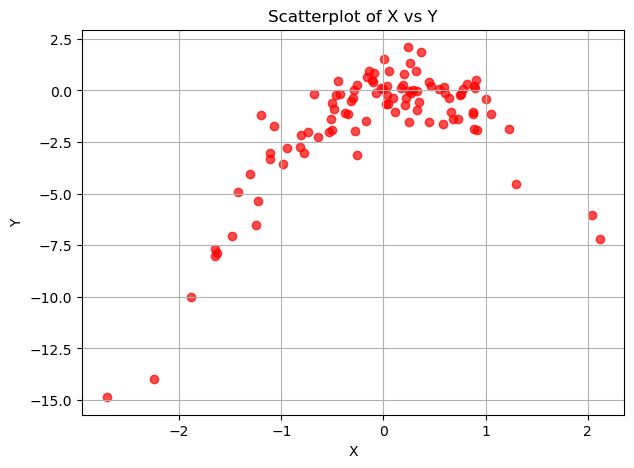

In [88]:
#(b)
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='red', alpha=0.7)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot of X vs Y')
plt.grid(True)
plt.show()

In [93]:
#(c)

df = pd.DataFrame({'X': x, 'Y': y})

def compute_loocv(df, degree):
    n = len(df)
    squared_errors = []
    X_poly = pd.DataFrame({'const': np.ones(n)})
    for p in range(1, degree + 1):
        X_poly[f'X_{p}'] = df['X'] ** p
        
    for i in range(n):
        # Leave out observation i
        X_train = X_poly.drop(index=i)
        y_train = df['Y'].drop(index=i)
        
        # Fit OLS model on remaining n-1 observations
        model = sm.OLS(y_train, X_train).fit()
        
        # Predict observation i
        X_test = X_poly.iloc[[i]]
        pred = model.predict(X_test).values[0]
        
        # Compute squared prediction error
        squared_errors.append((df['Y'].iloc[i] - pred) ** 2)
        
    return np.mean(squared_errors)

for degree in range(1, 5):
    mse = compute_loocv(df, degree)
    print(f"Model {degree} (Degree {degree}) LOOCV MSE: {mse:.4f}")

Model 1 (Degree 1) LOOCV MSE: 6.6330
Model 2 (Degree 2) LOOCV MSE: 1.1229
Model 3 (Degree 3) LOOCV MSE: 1.3018
Model 4 (Degree 4) LOOCV MSE: 1.3324


In [95]:
# (d)
rng2 = np.random.default_rng(2)
x2 = rng2.normal(size=100)
y2 = x2 - 2 * x2**2 + rng2.normal(size=100)

df2 = pd.DataFrame({'X': x2, 'Y': y2})

for p in range(1, 5):
    mse = compute_loocv(df2, p)
    print(f"Model {p} (Degree {p}) LOOCV MSE (Seed 2): {mse:.4f}")

Model 1 (Degree 1) LOOCV MSE (Seed 2): 7.5606
Model 2 (Degree 2) LOOCV MSE (Seed 2): 0.9840
Model 3 (Degree 3) LOOCV MSE (Seed 2): 0.9682
Model 4 (Degree 4) LOOCV MSE (Seed 2): 0.9660


(e)

**Which model had the smallest LOOCV error?**

In Seed 1 (c), **Model 2 (Quadratic)** had the smallest error (1.1229).

In Seed 2 (d), **Model 4** had a slightly lower error (0.9660), but it is virtually identical to **Model 2** (0.9840) and **Model 3** (0.968).



This is exactly what is expected.

The true underlying formula used to generate $Y$ is quadratic ($Y = X - 2X^2 + \epsilon$).

Degree 1 underfits the data significantly (high bias) because it tries to fit a straight line through a curved parabola.

Degree 2 accurately captures the true quadratic relationship.

Degrees 3 and 4 include unnecessary parameters ($\beta_3 X^3, \beta_4 X^4$) whose true population coefficients are $0$. Any minor difference in LOOCV error between Degrees 2, 3, and 4 is just random sample noise (variance).

In [102]:
#(f)

rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

df = pd.DataFrame({'X': x, 'Y': y})


for degree in range(1, 5):
    X_poly = pd.DataFrame({'const': np.ones(len(df))})
    for p in range(1, degree + 1):
        X_poly[f'X_{p}'] = df['X'] ** p
        
    model = sm.OLS(df['Y'], X_poly).fit()
    print(model.summary().tables[1])  

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4650      0.247     -5.937      0.000      -1.955      -0.975
X_1            1.9494      0.289      6.752      0.000       1.376       2.522
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0728      0.119     -0.611      0.543      -0.309       0.164
X_1            0.9663      0.126      7.647      0.000       0.715       1.217
X_2           -2.0047      0.091    -22.072      0.000      -2.185      -1.824
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0572      0.120     -0.477      0.635      -0.295       0.181
X_1            1.1146      0.187      5.945      0.0

yes, they strongly agree on the central finding: $X_1$ and $X_2$ are the core true predictors, and higher-order terms like $X_3$ add no meaningful value.

Exercise 9:

In [103]:
boston = pd.read_csv(r"C:\Users\Fatima zahra\Practice\ALL+CSV+FILES+-+2nd+Edition+-+corrected\ALL CSV FILES - 2nd Edition\Boston.csv")
boston = boston.dropna()

In [106]:
#(a) 
mu = boston['medv'].mean()
mu

np.float64(22.532806324110677)

(b): 

Standard Error of "mu", the formula for the standard error of the sample mean is:$$\text{SE}(\hat{\mu}) = \frac{s}{\sqrt{n}}$$

In [108]:
n = len(boston)
s = boston['medv'].std()

se_formula = s / np.sqrt(n)
print(f"Formula Standard Error of mu: {se_formula:.4f}")

Formula Standard Error of mu: 0.4089


In [109]:
# (c)

rng = np.random.default_rng(0)

B = 1000
boot_means = np.zeros(B)

for b in range(B):
    boot_idx = rng.choice(boston.index, size=n, replace=True)
    boot_means[b] = boston.loc[boot_idx, 'medv'].mean()

se_bootstrap = np.std(boot_means)
print(f"Bootstrap Standard Error of mu: {se_bootstrap:.4f}")

Bootstrap Standard Error of mu: 0.4125


In [111]:

rng = np.random.default_rng(0)
B = 1000
boot_means = [boston['medv'].sample(n=n, replace=True, random_state=i).mean() for i in range(B)]
se_boot = np.std(boot_means)  

ci_boot = (mu - 2 * se_boot, mu + 2 * se_boot)
ci_formula = (mu - 2 * se_formula, mu + 2 * se_formula)

print(f"95% CI using Bootstrap SE: [{ci_boot[0]:.4f}, {ci_boot[1]:.4f}]")
print(f"95% CI using Formula SE:   [{ci_formula[0]:.4f}, {ci_formula[1]:.4f}]")

95% CI using Bootstrap SE: [21.6799, 23.3857]
95% CI using Formula SE:   [21.7151, 23.3505]


In [113]:
#(e)

mu_med = boston['medv'].median()
mu_med

21.2

In [116]:
# (f)

rng = np.random.default_rng(0)
B = 1000
n = len(boston)

boot_medians = np.zeros(B)

for b in range(B):
    boot_idx = rng.choice(boston.index, size=n, replace=True)
    boot_medians[b] = boston.loc[boot_idx, 'medv'].median()

se_median = np.std(boot_medians)
print(f"Bootstrap Standard Error of mu_med: {se_median:.4f}")

Bootstrap Standard Error of mu_med: 0.3694


The standard error of the median  0.3694 is relatively small compared to the median estimate of 21.2. This indicates that the sample median is an accurate estimator of the true population median.

In [118]:
mu_01 = np.percentile(boston['medv'], 10)
print(f"Estimated 10th percentile (mu_01): {mu_01:.4f}")

Estimated 10th percentile (mu_01): 12.7500


In [119]:
# (h)
boot_percentiles = np.zeros(B)

for b in range(B):
    boot_idx = rng.choice(boston.index, size=n, replace=True)
    boot_percentiles[b] = np.percentile(boston.loc[boot_idx, 'medv'], 10)

se_01 = np.std(boot_percentiles)
print(f"Bootstrap Standard Error of mu_01: {se_01:.4f}")

Bootstrap Standard Error of mu_01: 0.5066


The standard error for the 10th percentile (0.50) is slightly higher than that of the mean (0.41) and median (0.36). Quantiles at the tails of a distribution (such as the 10th or 90th percentile) rely on fewer observations in their immediate neighborhood, resulting in slightly higher variability across bootstrap samples.